In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
import time

In [ ]:
#data_preprocess
df = pd.read_csv(r"D:\projects\Student Academic Performance\student_performance.csv")
df = df.drop(columns=['student_id', 'final_score'])
X = df.drop(columns=['passed'])
y = df['passed']
y = y.map({'Yes': 1 , 'No' : 0})
categorical_cols = ['gender', 'parent_education', 'internet_access', 'extracurricular']
for col in categorical_cols:
    X[col] = X[col].astype('category')
    
X_train,X_test,y_train,y_test=train_test_split(X ,y ,test_size=0.2 , random_state=42)



,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score
249,Male,19,3,96.7,High School,No,Yes,66
433,Female,16,4,91.2,Master,No,No,73
19,Female,18,30,75.9,High School,Yes,Yes,38
322,Female,17,20,63.4,NaN,Yes,Yes,82
332,Male,19,9,76.0,PhD,Yes,Yes,73
...,...,...,...,...,...,...,...,...
106,Female,18,23,89.6,Bachelor,No,Yes,46
270,Male,19,17,59.2,NaN,Yes,Yes,39
348,Female,15,17,93.0,Bachelor,No,Yes,62
435,Male,16,8,86.7,NaN,Yes,Yes,76


In [17]:
#prepare_the_model
model = xgboost.XGBClassifier(enable_categorical=True)
params_= {
    'max_depth': [3,5,7,8],
    'n_estimators': [30,50 ,100 ,200],
    'learning_rate' : [0.01 , 0.1 , 0.5],
    'subsample' : [0.8 , 1],
    'colsample_bytree': [0.8, 1.0]
}
Grid_ = GridSearchCV(
    estimator=model,
    param_grid=params_,
    cv=5,
    n_jobs=-1,
    scoring='f1',
    
)

In [18]:
#train
print('the model training process has started')
start_time = time.time()
Grid_.fit(X_train,y_train)
end_time = time.time()
print(f'the model training process has ended in {end_time - start_time:.2f}')

print("\n -----Best Paramaters-----")
print(Grid_.best_params_)


the model training process has started
the model training process has ended in 10.77

 -----Best Paramaters-----
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}


In [20]:
#evaluation
best_model = Grid_.best_estimator_
y_pred = best_model.predict(X_test)
f1 = f1_score(y_test,y_pred)
print(f"F1 score is {f1:.4f}")

F1 score is 0.8905


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

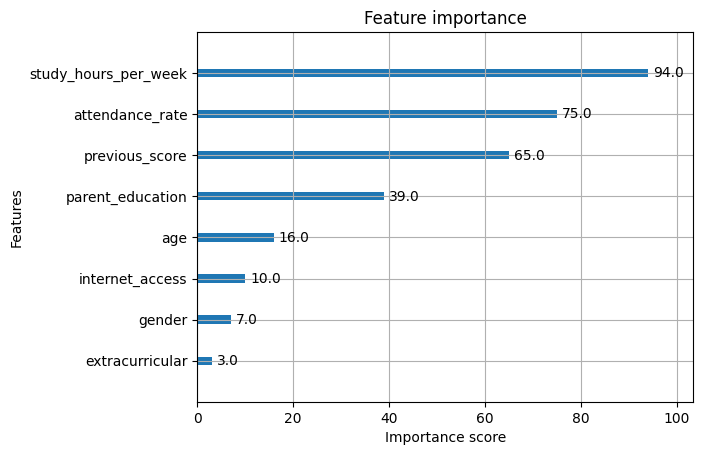

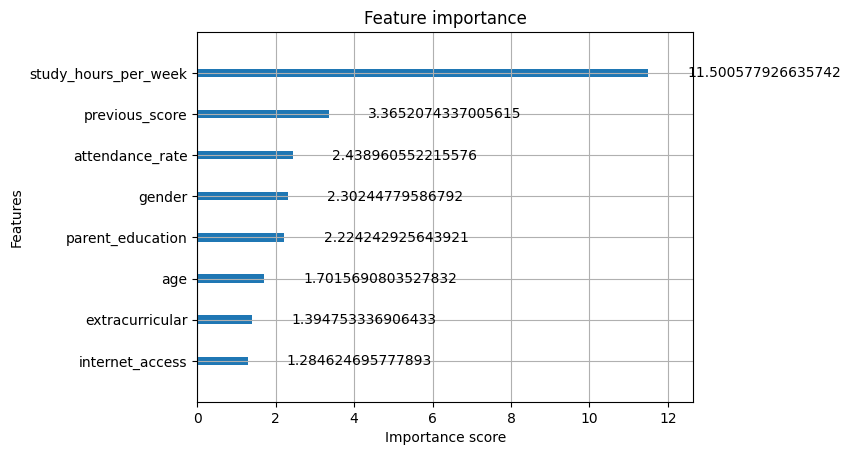

In [ ]:
#weight
xgboost.plot_importance(best_model)
#gain
xgboost.plot_importance(best_model , importance_type='gain')